In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED']      = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f'TensorFlow version : {tf.__version__}')
print(f'Random seed set to  : {SEED}')


TensorFlow version : 2.20.0
Random seed set to  : 42


In [4]:
RESULTS_DIR = '/content/drive/MyDrive/ME15/results/'
MODEL_DIR   = '/content/drive/MyDrive/ME15/model/'

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,   exist_ok=True)
print('Results will be saved to:', RESULTS_DIR)
print('Models  will be saved to:', MODEL_DIR)


Results will be saved to: /content/drive/MyDrive/ME15/results/
Models  will be saved to: /content/drive/MyDrive/ME15/model/


In [5]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPUs available: {len(gpus)}')
    for gpu in gpus:
        print(f' - {gpu}')
else:
    print('No GPU found — training will run on CPU.')


GPUs available: 1
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [6]:
import kagglehub

# Dataset: abdallahalidev/plantvillage-dataset
# Structure:
#   color/      Tomato___Late_blight/
#               Tomato___healthy/
#               ... (38 total classes)
#   grayscale/  (same structure)
#   segmented/  (same structure)
#
# We use ONLY the color/ variant and filter for Tomato__healthy
# and Tomato___Late_blight folders.

path = kagglehub.dataset_download('abdallahalidev/plantvillage-dataset')
print('Path to dataset files:', path)


Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Path to dataset files: /kaggle/input/plantvillage-dataset


In [7]:
# Walk top levels to confirm structure
for root, dirs, files in os.walk(path):
    depth = root.replace(path, '').count(os.sep)
    if depth <= 2:
        n_files = len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        label   = f'  ({n_files} images)' if n_files else ''
        print(' ' * depth * 2 + Path(root).name + label)
    if depth >= 2:
        dirs[:] = []


plantvillage-dataset
  plantvillage dataset
    segmented
    grayscale
    color


In [8]:
# Locate Tomato___healthy and Tomato___Late_blight under color/ only.
# Uses substring matching on lowercased folder name.
# Skips grayscale/ and segmented/ by requiring parent == 'color'.

found = {}
for dirpath, dirnames, filenames in os.walk(path):
    base   = Path(dirpath).name.lower()
    parent = Path(dirpath).parent.name.lower()
    if parent != 'color':
        continue
    if 'tomato' in base and 'healthy' in base:
        found['healthy'] = dirpath
    elif 'tomato' in base and 'late' in base and 'blight' in base:
        found['late_blight'] = dirpath

healthy_dir    = found.get('healthy')
late_blight_dir = found.get('late_blight')

print('Healthy dir    :', healthy_dir)
print('Late Blight dir:', late_blight_dir)

if not healthy_dir or not late_blight_dir:
    raise FileNotFoundError(
        'Could not locate both class folders. Check the directory walk output above.'
    )


Healthy dir    : /kaggle/input/plantvillage-dataset/plantvillage dataset/color/Tomato___healthy
Late Blight dir: /kaggle/input/plantvillage-dataset/plantvillage dataset/color/Tomato___Late_blight


In [9]:
def count_images(d):
    if d is None or not Path(d).exists():
        return 0
    exts = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')
    return sum(len(list(Path(d).rglob(e))) for e in exts)

n_healthy    = count_images(healthy_dir)
n_late_blight = count_images(late_blight_dir)
print(f'Healthy     images: {n_healthy}')
print(f'Late Blight images: {n_late_blight}')


Healthy     images: 1591
Late Blight images: 1909


In [10]:
# Build train / val / test split — 70% train | 15% val | 15% test (per class)

SPLIT_ROOT  = '/content/tomato_split'
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15

CLASS_MAP = {
    'Tomato_healthy':    healthy_dir,
    'Tomato_Late_blight': late_blight_dir,
}

def build_split_dirs(split_root, class_map, train_ratio, val_ratio, seed=42):
    """Copy images into split_root/train|val|test/<class> folders."""
    split_root = Path(split_root)
    if split_root.exists():
        shutil.rmtree(split_root)

    rng   = random.Random(seed)
    exts  = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
    stats = {}

    for cls_name, src_dir in class_map.items():
        imgs = [p for p in Path(src_dir).rglob('*') if p.suffix in exts]
        rng.shuffle(imgs)

        n      = len(imgs)
        n_train = int(n * train_ratio)
        n_val   = int(n * val_ratio)

        splits = {
            'train': imgs[:n_train],
            'val':   imgs[n_train:n_train + n_val],
            'test':  imgs[n_train + n_val:],
        }
        stats[cls_name] = {k: len(v) for k, v in splits.items()}

        for split_name, split_imgs in splits.items():
            dest = split_root / split_name / cls_name
            dest.mkdir(parents=True, exist_ok=True)
            for img in split_imgs:
                shutil.copy(img, dest / img.name)

    return stats

split_stats = build_split_dirs(SPLIT_ROOT, CLASS_MAP, TRAIN_RATIO, VAL_RATIO)
print('Split complete:')
for cls, counts in split_stats.items():
    print(f'  {cls}: {counts}')


Split complete:
  Tomato_healthy: {'train': 1113, 'val': 238, 'test': 240}
  Tomato_Late_blight: {'train': 1336, 'val': 286, 'test': 287}


In [11]:
for split in ('train', 'val', 'test'):
    split_path = Path(SPLIT_ROOT) / split
    total = count_images(split_path)
    print(f'{split:>5} : {total} total')
    for cls_dir in sorted(split_path.iterdir()):
        print(f'         {cls_dir.name:<25}: {count_images(cls_dir)}')


train : 2449 total
         Tomato_Late_blight       : 1336
         Tomato_healthy           : 1113
  val : 524 total
         Tomato_Late_blight       : 286
         Tomato_healthy           : 238
 test : 527 total
         Tomato_Late_blight       : 287
         Tomato_healthy           : 240


In [12]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH  = 224
BATCH_SIZE   = 32
EPOCHS       = 20
LR           = 1e-4

print(f'Image size   : {IMAGE_HEIGHT} x {IMAGE_WIDTH}')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Max epochs   : {EPOCHS}')
print(f'Learning rate: {LR}')


Image size   : 224 x 224
Batch size   : 32
Max epochs   : 20
Learning rate: 0.0001


In [13]:
train_dir = Path(SPLIT_ROOT) / 'train'
val_dir   = Path(SPLIT_ROOT) / 'val'
test_dir  = Path(SPLIT_ROOT) / 'test'

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, label_mode='binary',
    seed=SEED, shuffle=True,
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, label_mode='binary',
    seed=SEED, shuffle=False,
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, label_mode='binary',
    seed=SEED, shuffle=False,
)


Found 2449 files belonging to 2 classes.
Found 524 files belonging to 2 classes.
Found 527 files belonging to 2 classes.


In [14]:
class_names = train_dataset.class_names
print(f'Classes: {class_names}')
# Expected: ['Tomato_Late_blight', 'Tomato_healthy']  (alphabetical)
# raw_prob = P(Tomato_healthy) = P(CLASS_NAMES[1])

if len(class_names) != 2:
    print(f'WARNING: expected 2 classes, found {len(class_names)}: {class_names}')


Classes: ['Tomato_Late_blight', 'Tomato_healthy']


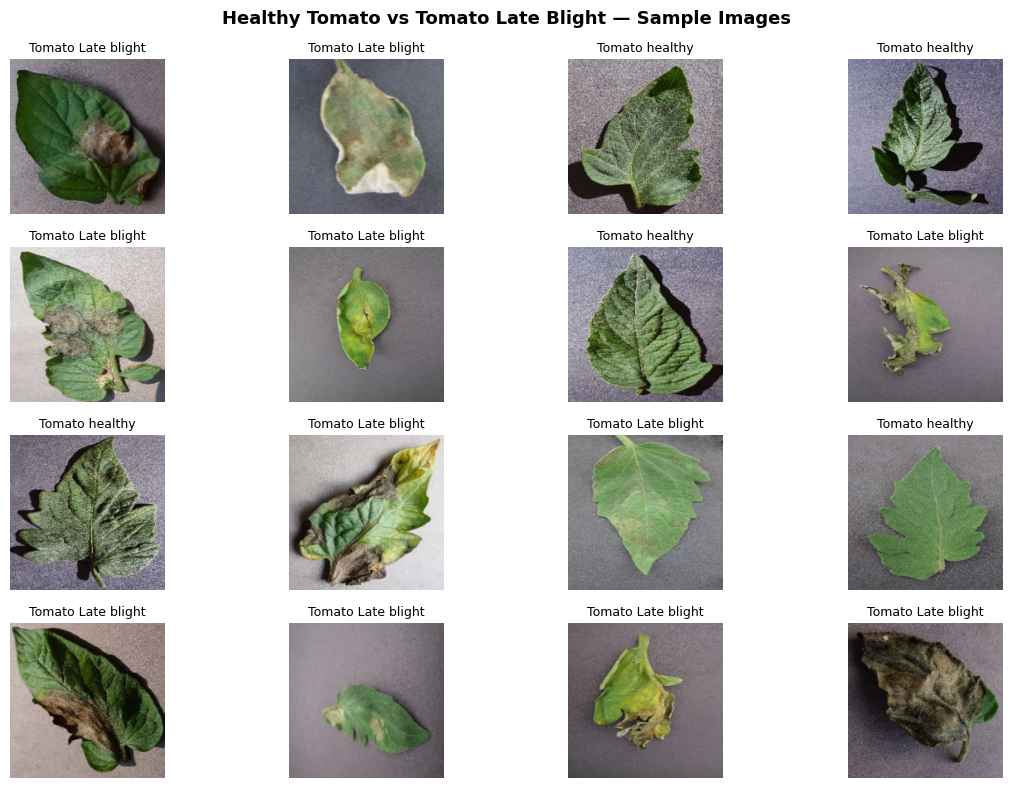

Saved: /content/drive/MyDrive/ME15/results/sample_images.png


In [15]:
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    label_idx = int(fixed_labels[i][0])
    plt.title(class_names[label_idx].replace('_', ' '), fontsize=9)
    plt.axis('off')

plt.suptitle('Healthy Tomato vs Tomato Late Blight — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR + 'sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved:', RESULTS_DIR + 'sample_images.png')


In [16]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset   = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset  = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print('Pipeline optimised with cache + shuffle + prefetch.')


Pipeline optimised with cache + shuffle + prefetch.


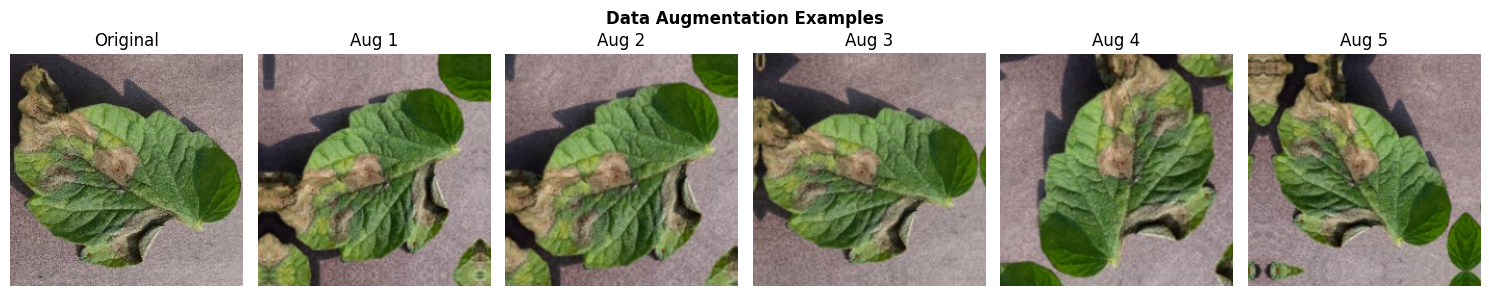

In [17]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
], name='data_augmentation')

for images, _ in train_dataset.take(1):
    sample = images[0:1]
    break

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original')
axes[0].axis('off')
for i in range(1, 6):
    aug = data_augmentation(sample, training=True)
    axes[i].imshow(aug[0].numpy().astype('uint8'))
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR + 'augmentation_examples.png', dpi=120, bbox_inches='tight')
plt.show()


In [18]:
def make_callbacks(name, model_dir=MODEL_DIR):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(model_dir, f'{name}_best.keras'),
            monitor='val_accuracy', save_best_only=True, verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=6,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3,
            min_lr=1e-7, verbose=1,
        ),
    ]


In [19]:
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)

def build_transfer_model(input_shape, augmentation):
    base_model = tf.keras.applications.MobileNetV2(
        weights='imagenet',
        input_shape=input_shape,
        include_top=False,
    )
    preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input

    # Freeze the base model for the feature-extraction phase
    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs, training=True)
    x = preprocess_fn(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    return model, base_model

tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation)
tl_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
def plot_learning_curves(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'],     label='Train Acc')
    ax1.plot(history.history['val_accuracy'], label='Val Acc')
    ax1.set_title(f'{title} — Accuracy')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True)

    ax2.plot(history.history['loss'],     label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title(f'{title} — Loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    safe = title.lower().replace(' ', '_').replace('—', '').replace('__', '_')
    plt.savefig(RESULTS_DIR + f'learning_curves_{safe}.png', dpi=120, bbox_inches='tight')
    plt.show()


def evaluate_model(model, dataset, class_names, title):
    y_true, y_pred_raw = [], []
    for imgs, lbls in dataset:
        preds = model.predict(imgs, verbose=0)
        y_pred_raw.extend(preds.flatten())
        y_true.extend(lbls.numpy().flatten())

    y_pred = [1 if p >= 0.5 else 0 for p in y_pred_raw]

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    print(f'\n{title}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1 Score : {f1:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {title}')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    safe = title.lower().replace(' ', '_').replace('—', '').replace('__', '_')
    plt.savefig(RESULTS_DIR + f'confusion_matrix_{safe}.png', dpi=120, bbox_inches='tight')
    plt.show()
    return acc


In [21]:
# Phase 1 — Feature Extraction (base frozen)
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

tl_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks('mobilenetv2_tomato_feature_extraction'),
    verbose=1,
)


Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8496 - loss: 0.3731
Epoch 1: val_accuracy improved from None to 0.95802, saving model to /content/drive/MyDrive/ME15/model/mobilenetv2_tomato_feature_extraction_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ME15/model/mobilenetv2_tomato_feature_extraction_best.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.9171 - loss: 0.2454 - val_accuracy: 0.9580 - val_loss: 0.1286 - learning_rate: 1.0000e-04
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9829 - loss: 0.0879
Epoch 2: val_accuracy improved from 0.95802 to 0.97328, saving model to /content/drive/MyDrive/ME15/model/mobilenetv2_tomato_feature_extraction_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ME15/model/mobilenetv2_tomato_feature_extraction_best.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.9837 - loss: 0.0787 - val_accuracy: 0.9733 - val_loss: 0.0821 - learning_rate: 1.0000e-0

MobileNetV2 TL -> val_loss    : 0.0212
MobileNetV2 TL -> val_accuracy: 0.9943


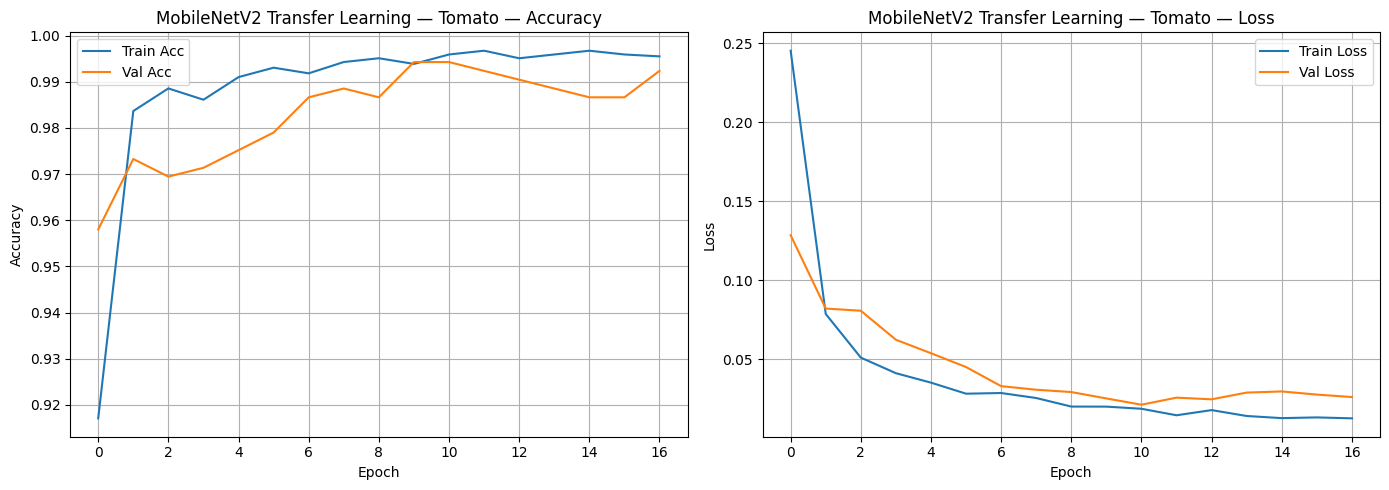

In [22]:
tl_val_loss, tl_val_acc = tl_model.evaluate(val_dataset, verbose=0)
print(f'MobileNetV2 TL -> val_loss    : {tl_val_loss:.4f}')
print(f'MobileNetV2 TL -> val_accuracy: {tl_val_acc:.4f}')

plot_learning_curves(tl_history, 'MobileNetV2 Transfer Learning — Tomato')



MobileNetV2 Transfer — Tomato
  Accuracy : 0.9981
  Precision: 0.9959
  Recall   : 1.0000
  F1 Score : 0.9979

                    precision    recall  f1-score   support

Tomato_Late_blight       1.00      1.00      1.00       287
    Tomato_healthy       1.00      1.00      1.00       240

          accuracy                           1.00       527
         macro avg       1.00      1.00      1.00       527
      weighted avg       1.00      1.00      1.00       527



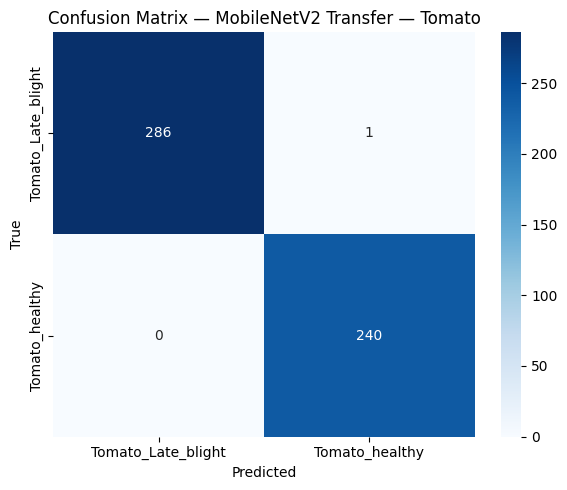

In [23]:
tl_test_acc = evaluate_model(
    tl_model, test_dataset, class_names,
    'MobileNetV2 Transfer — Tomato'
)


In [24]:
# Phase 2 — Fine-Tuning (unfreeze top 30 layers)
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers after unfreezing: {trainable_count} / {len(base_model.layers)}')


Trainable base layers after unfreezing: 30 / 154


In [25]:
FINETUNE_LR = LR / 10   # 1e-5

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)


In [26]:
ft_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=make_callbacks('mobilenetv2_tomato_finetuned'),
    verbose=1,
)


Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7909 - loss: 0.5745
Epoch 1: val_accuracy improved from None to 0.96565, saving model to /content/drive/MyDrive/ME15/model/mobilenetv2_tomato_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ME15/model/mobilenetv2_tomato_finetuned_best.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 118ms/step - accuracy: 0.8844 - loss: 0.3066 - val_accuracy: 0.9656 - val_loss: 0.1149 - learning_rate: 1.0000e-05
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9777 - loss: 0.0580
Epoch 2: val_accuracy did not improve from 0.96565
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.9804 - loss: 0.0512 - val_accuracy: 0.9637 - val_loss: 0.1272 - learning_rate: 1.0000e-05
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9918 - loss: 0.0331
Epoch 3: val_accuracy did not improve from 0.96565
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.9894 - loss: 0.0330 - val_accuracy: 0.9637 - va

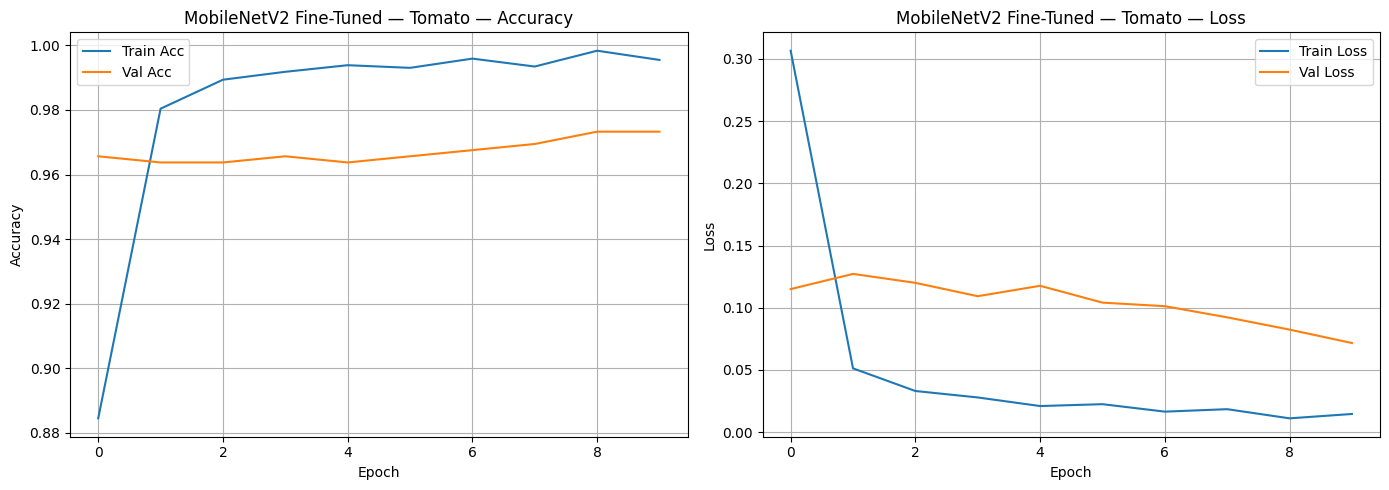


MobileNetV2 Fine-Tuned — Tomato
  Accuracy : 0.9829
  Precision: 0.9639
  Recall   : 1.0000
  F1 Score : 0.9816

                    precision    recall  f1-score   support

Tomato_Late_blight       1.00      0.97      0.98       287
    Tomato_healthy       0.96      1.00      0.98       240

          accuracy                           0.98       527
         macro avg       0.98      0.98      0.98       527
      weighted avg       0.98      0.98      0.98       527



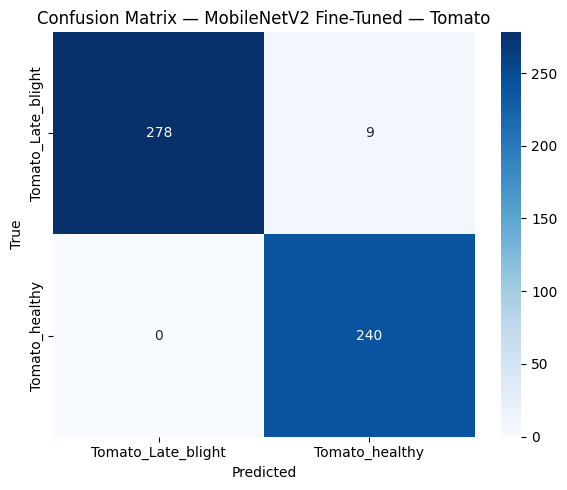


--- Summary ---
Feature-extraction test accuracy : 0.9981
Fine-tuned         test accuracy : 0.9829


In [27]:
plot_learning_curves(ft_history, 'MobileNetV2 Fine-Tuned — Tomato')

ft_test_acc = evaluate_model(
    tl_model, test_dataset, class_names,
    'MobileNetV2 Fine-Tuned — Tomato'
)

print('\n--- Summary ---')
print(f'Feature-extraction test accuracy : {tl_test_acc:.4f}')
print(f'Fine-tuned         test accuracy : {ft_test_acc:.4f}')


In [28]:
def predict_image(img_path, model, class_names, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH)):
    """Load an image file and classify it with the trained model."""
    img       = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')

    prob  = float(model.predict(img_array, verbose=0)[0][0])
    idx   = int(prob >= 0.5)
    label = class_names[idx]
    conf  = prob if prob >= 0.5 else 1.0 - prob
    plt.title(f'Predicted: {label}  ({conf*100:.1f}%)', fontsize=12)
    plt.tight_layout()
    plt.show()
    return label, conf


In [29]:
FINAL_MODEL_PATH = '/content/drive/MyDrive/ME15/model/tomato_blight_model.keras'
tl_model.save(FINAL_MODEL_PATH)

print('Model saved:')
print(f'  {FINAL_MODEL_PATH}')
print(f'  Final test accuracy: {ft_test_acc:.4f}')


Model saved:
  /content/drive/MyDrive/ME15/model/tomato_blight_model.keras
  Final test accuracy: 0.9829


In [30]:
# ── Generate class_stats.npz for OOD Layer 2 ─────────────────────────────────────────────
# Run this cell ONCE after training.
# We reload val images directly from disk (no augmentation pipeline) so the
# per-class feature statistics are clean and stable — matching what app.py
# sees at inference time.

import numpy as np
import keras

CLASS_STATS_PATH = FINAL_MODEL_PATH.replace(FINAL_MODEL_PATH.split('/')[-1], 'class_stats.npz')

# Load the saved model
saved_model = keras.models.load_model(FINAL_MODEL_PATH)
print('Model loaded from:', FINAL_MODEL_PATH)

# Build feature extractor: model.input → GlobalAveragePooling2D
gap_layer = next(
    l for l in reversed(saved_model.layers)
    if isinstance(l, keras.layers.GlobalAveragePooling2D)
)
feature_extractor = keras.Model(
    inputs=saved_model.input,
    outputs=gap_layer.output,
    name='feature_extractor',
)
print(f'Feature extractor output shape: {feature_extractor.output_shape}')

# Reload val set FRESH from disk (no cache, no augmentation)
# This ensures features match exactly what app.py computes at inference time.
val_dataset_clean = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=SEED,
    shuffle=False,
)

# Collect features and labels
all_features, all_labels = [], []
for imgs, lbls in val_dataset_clean:
    feats = feature_extractor(imgs, training=False).numpy()
    all_features.append(feats)
    all_labels.append(lbls.numpy().flatten())

all_features = np.concatenate(all_features, axis=0)  # (N, 1280)
all_labels   = np.concatenate(all_labels,   axis=0)  # (N,)
print(f'Collected {len(all_features)} val samples, feature dim={all_features.shape[1]}')

# Compute per-class mean and std
class_means, class_stds = [], []
for idx, name in enumerate(class_names):
    mask        = all_labels == idx
    class_feats = all_features[mask]
    class_means.append(class_feats.mean(axis=0))
    class_stds.append(class_feats.std(axis=0) + 1e-8)  # avoid div-by-zero
    print(f'  {name}: {mask.sum()} samples')

class_means = np.array(class_means)  # (n_classes, 1280)
class_stds  = np.array(class_stds)   # (n_classes, 1280)

# Save to Drive
np.savez(CLASS_STATS_PATH, means=class_means, stds=class_stds, class_names=class_names)
print(f'\nclass_stats.npz saved to: {CLASS_STATS_PATH}')
print('OOD Layer 2 is now enabled in the Streamlit app.')


Model loaded from: /content/drive/MyDrive/ME15/model/tomato_blight_model.keras
Feature extractor output shape: (None, 1280)
Collected 524 val samples, feature dim=1280
  Tomato_Late_blight: 286 samples
  Tomato_healthy: 238 samples

class_stats.npz saved to: /content/drive/MyDrive/ME15/model/class_stats.npz
OOD Layer 2 is now enabled in the Streamlit app.
